# 02 · Exploratory Data Analysis (Person A)

**Scope of this notebook:** products, customers, revenue over time, weekday and hour patterns, revenue concentration (Pareto) and dead stock.
Geography, basket size, returns and seasonality are covered in the second EDA notebook.

**Notebook map**
1. Setup and analysis dataset
2. Top products
3. Top customers
4. Revenue over time
5. Weekday and hour patterns
6. Pareto: revenue concentration
7. Dead stock
8. Business insights

## 1. Setup and analysis dataset

We start from the structurally cleaned file produced in `01_cleaning`. For product and revenue analysis we also need to separate real product activity from fees and adjustments, and we must **net out cancellations**.

**Provisional rules (to be replaced by the transactional cleaning)**
- A line is a *product line* when `StockCode` looks like a product code (five digits, optionally followed by letters, which excludes `POST`, `M`, `BANK CHARGES`, `AMAZONFEE`) and `UnitPrice > 0`.
- `lines` holds every product line, **including cancellation lines with their negative quantity**. Revenue and units computed from `lines` are therefore **net**: a cancelled order nets out to zero.
- `sales` holds only the purchase lines (not cancellations, `Quantity > 0`). It is used for counting invoices and customers and for dates of last sale.

**Why netting matters:** an order that was later cancelled in full would otherwise count as revenue and could rank among the top products or customers. Every revenue figure below is net unless stated otherwise. Once the final cleaned file is available, only the cell that builds `lines` and `sales` needs to change.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "figure.figsize": (10, 4.5), "figure.dpi": 100,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

DATA = Path("../data")
FIG = Path("../reports/figures")
FIG.mkdir(parents=True, exist_ok=True)

def save(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=150, bbox_inches="tight")

df = pd.read_parquet(DATA / "interim_structural.parquet")
print("Structural dataset:", df.shape)

Structural dataset: (536641, 13)


In [2]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

is_cancel = df["InvoiceNo"].str.startswith("C")
is_product = df["StockCode"].str.match(r"^\d{5}").fillna(False).astype(bool)

# overlapping reasons, shown for transparency
reasons = pd.Series({
    "All lines": len(df),
    "Cancellation invoices (C...)": int(is_cancel.sum()),
    "Non-product stock codes": int((~is_product).sum()),
    "UnitPrice <= 0": int((df["UnitPrice"] <= 0).sum()),
    "Quantity <= 0 (not cancellations)": int(((df["Quantity"] <= 0) & ~is_cancel).sum()),
})
print(reasons.to_string(), "\n")

# every product line with a real price; cancellations keep their negative quantity (net view)
lines = df[is_product & (df["UnitPrice"] > 0)].copy()
lines_known = lines[lines["HasCustomer"]].copy()

# purchase lines only: used to count invoices, customers and last-sale dates
sales = lines[~lines["InvoiceNo"].str.startswith("C") & (lines["Quantity"] > 0)].copy()
sales_known = sales[sales["HasCustomer"]].copy()

gross = sales["Revenue"].sum()
net = lines["Revenue"].sum()
print(f"Gross sales revenue      : {gross:,.0f}")
print(f"Value cancelled/returned : {gross - net:,.0f}")
print(f"Net revenue              : {net:,.0f}")
print(f"Purchase lines           : {len(sales):,} ({len(sales)/len(df):.1%} of all lines)")
print(f"Invoices                 : {sales['InvoiceNo'].nunique():,}")
print(f"Known customers          : {sales_known['CustomerID'].nunique():,}")
print(f"Share of net revenue from known customers: {lines_known['Revenue'].sum()/net:.1%}")
print("Period:", sales["InvoiceDate"].min().date(), "->", sales["InvoiceDate"].max().date())

# most common description per product code
desc = (sales.dropna(subset=["Description"])
             .groupby("StockCode")["Description"]
             .agg(lambda s: s.mode().iat[0]))

All lines                            536641
Cancellation invoices (C...)           9251
Non-product stock codes                2989
UnitPrice <= 0                         2512
Quantity <= 0 (not cancellations)      1336 

Gross sales revenue      : 10,246,821
Value cancelled/returned : 475,901
Net revenue              : 9,770,920
Purchase lines           : 522,504 (97.4% of all lines)
Invoices                 : 19,773
Known customers          : 4,334
Share of net revenue from known customers: 84.6%
Period: 2010-12-01 -> 2011-12-09


### What the summary tells us
- **Cancellations matter.** Gross sales revenue is £10.25M, but £475,901 (4.6%) was later cancelled or returned, so **net revenue is £9.77M**. Every revenue figure in this notebook is net.
- **Almost all the data is usable.** 97.4% of the lines are real purchase lines, covering 19,773 invoices and 4,334 known customers.
- **Guest orders are a real share of the business.** Known customers account for 84.6% of net revenue, so about 15.4% comes from guest orders. The segmentation (RFM) will therefore describe roughly 85% of revenue. The earlier cleaning notebook reported 14.9% because it measured all lines, including fees and before netting; the small gap is the different basis, not an error.

### Check: which products have the most cancelled units?

Products whose units are largely cancelled would rank high on gross figures but contribute little real revenue. This table shows the biggest gaps between gross and net units.

In [3]:
units = pd.DataFrame({
    "GrossUnits": sales.groupby("StockCode")["Quantity"].sum(),
    "NetUnits": lines.groupby("StockCode")["Quantity"].sum(),
})
units["ReturnedUnits"] = units["GrossUnits"] - units["NetUnits"]
units["Description"] = desc.reindex(units.index)
units.nlargest(8, "ReturnedUnits")[["Description", "GrossUnits", "ReturnedUnits", "NetUnits"]]

,Description,GrossUnits,ReturnedUnits,NetUnits
StockCode,,,,
23843,"PAPER CRAFT , LITTLE BIRDIE","80,995.00","80,995.00",0
23166,MEDIUM CERAMIC TOP STORAGE JAR,"78,033.00","74,494.00",3539
84347,ROTATING SILVER ANGELS T-LIGHT HLDR,"9,461.00","9,376.00",85
21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,"10,241.00","3,150.00",7091
85123A,WHITE HANGING HEART T-LIGHT HOLDER,"37,641.00","2,578.00",35063
21175,GIN + TONIC DIET METAL SIGN,"12,207.00","2,030.00",10177
22920,HERB MARKER BASIL,"3,423.00","1,527.00",1896
22273,FELTCRAFT DOLL MOLLY,"4,509.00","1,447.00",3062


### What the cancelled-units table tells us
- **PAPER CRAFT, LITTLE BIRDIE:** all 80,995 units were returned, so the net is **0**. On gross figures it would have looked like a top product.
- **MEDIUM CERAMIC TOP STORAGE JAR:** 74,494 of 78,033 units (95%) were returned, leaving 3,539. **ROTATING SILVER ANGELS T-LIGHT HLDR:** 9,376 of 9,461 units (99%) were returned, leaving 85.
- **Normal products also have returns, at a much lower rate:** about 31% of FAIRY CAKE FLANNEL units, 17% of GIN + TONIC DIET METAL SIGN and 7% of WHITE HANGING HEART T-LIGHT HOLDER.

**Why it matters:** the first three rows are single large orders that were reversed. Counting them would have inflated product and customer rankings, so netting is necessary and the same rule must be used when computing Monetary value in RFM.

## 2. Top products

Which products sell the most units, and which earn the most revenue (both net of cancellations)? A product can sell many units at a low price and still rank low on revenue, so we compare both rankings.

Products with non-positive net units or revenue (excluded): 12


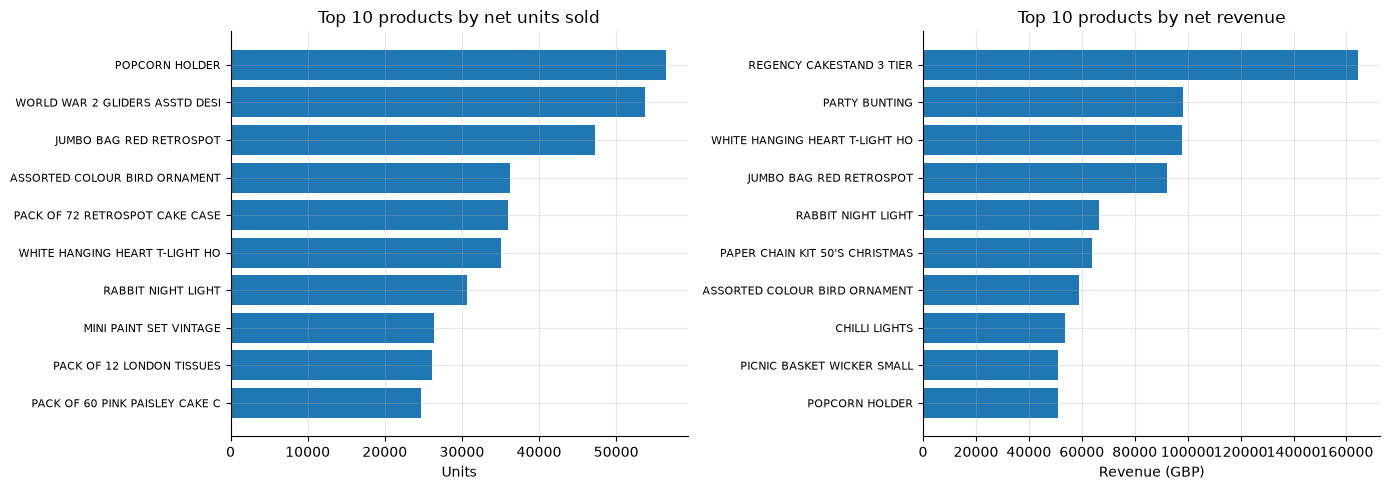

Products in both top-10 lists: 5
Top-10 revenue share of total: 8.2%


,Description,Units,Revenue,Invoices
StockCode,,,,
22423,REGENCY CAKESTAND 3 TIER,12996,"164,459.49",1988
47566,PARTY BUNTING,18006,"98,243.88",1685
85123A,WHITE HANGING HEART T-LIGHT HOLDER,35063,"97,838.45",2198
85099B,JUMBO BAG RED RETROSPOT,47256,"92,175.79",2089
23084,RABBIT NIGHT LIGHT,30631,"66,661.63",994
22086,PAPER CHAIN KIT 50'S CHRISTMAS,18876,"63,715.24",1160
84879,ASSORTED COLOUR BIRD ORNAMENT,36282,"58,792.42",1455
79321,CHILLI LIGHTS,10222,"53,746.66",661
22502,PICNIC BASKET WICKER SMALL,1862,"51,023.52",463


In [4]:
prod = lines.groupby("StockCode").agg(Units=("Quantity", "sum"), Revenue=("Revenue", "sum"))
prod = prod.join(
    sales.groupby("StockCode").agg(
        Invoices=("InvoiceNo", "nunique"),
        FirstSale=("InvoiceDate", "min"),
        LastSale=("InvoiceDate", "max"),
    ),
    how="inner",
)
prod["Description"] = desc.reindex(prod.index).fillna("(no description)")

prod["Revenue"] = prod["Revenue"].round(2)   # removes floating-point residue left by netting
n_before = len(prod)
prod = prod[(prod["Revenue"] > 0) & (prod["Units"] > 0)]
print(f"Products with non-positive net units or revenue (excluded): {n_before - len(prod)}")

top_units = prod.nlargest(10, "Units")
top_rev = prod.nlargest(10, "Revenue")

def hbar(ax, data, col, title, xlabel):
    d = data.sort_values(col)
    ax.barh(range(len(d)), d[col].values)
    ax.set_yticks(range(len(d)))
    ax.set_yticklabels([t[:30] for t in d["Description"]], fontsize=8)
    ax.set_title(title)
    ax.set_xlabel(xlabel)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
hbar(axes[0], top_units, "Units", "Top 10 products by net units sold", "Units")
hbar(axes[1], top_rev, "Revenue", "Top 10 products by net revenue", "Revenue (GBP)")
plt.tight_layout()
save(fig, "top_products")
plt.show()

both = set(top_units.index) & set(top_rev.index)
print("Products in both top-10 lists:", len(both))
print("Top-10 revenue share of total: {:.1%}".format(top_rev["Revenue"].sum() / prod["Revenue"].sum()))
top_rev[["Description", "Units", "Revenue", "Invoices"]]

### What the product charts show
- **Volume and revenue give different winners.** Only 5 of the 10 products appear in both charts. The reason is price: POPCORN HOLDER sold the most units (56,427) but earned about £50,968 (roughly £0.90 per unit), while REGENCY CAKESTAND 3 TIER sold 12,996 units and earned £164,459 (roughly £12.65 per unit), the clear number one by revenue.
- **No single hero product.** The ten best products together make up only 8.2% of revenue, and the best one alone about 1.7%. Revenue is spread across a broad range of items.
- **The best sellers are ordered repeatedly.** The Regency Cakestand, White Hanging Heart T-Light Holder and Jumbo Bag Red Retrospot each appear on roughly 2,000 invoices, so their revenue comes from many orders rather than a few large ones.

**Why it matters:** products should be judged by revenue (or margin), not by units. High-volume, low-price items add handling work but little revenue.

## 3. Top customers

Known customers only. We look at who spends the most, how often they order, and how concentrated revenue is across customers. The heavy skew seen here is the reason for the log transform before clustering.

Customers with non-positive net revenue (excluded): 9
Customers: 4,325
Mean revenue per customer  : 1,912
Median revenue per customer: 648
Top 10 customers' share of known revenue : 16.6%
Top 20% of customers' share of revenue   : 73.8%
Customers with a single order: 34.6%


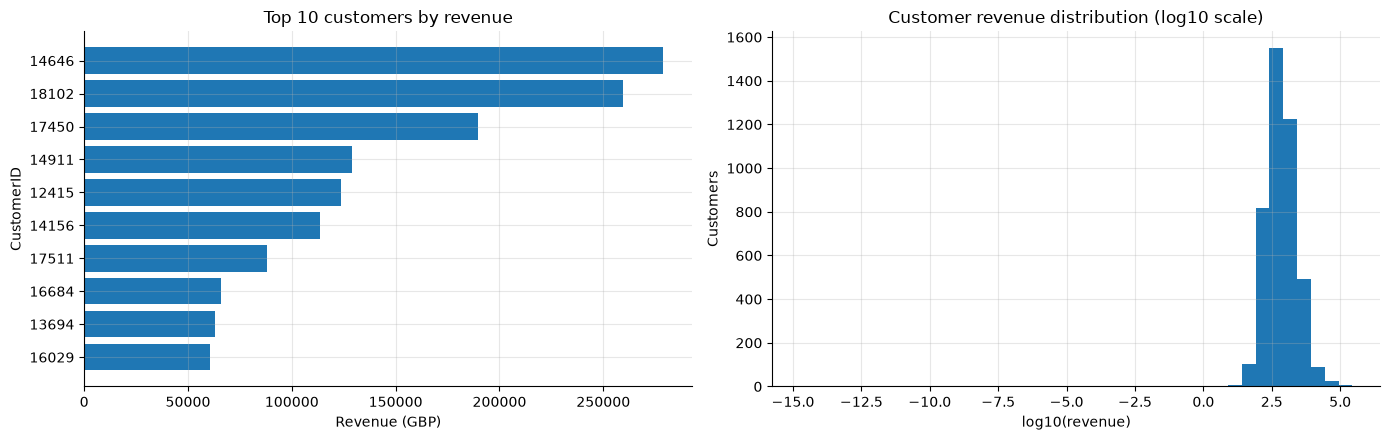

,Revenue,Orders,Country,AvgOrderValue
CustomerID,,,,
14646,"278,778.02",72,Netherlands,"3,871.92"
18102,"259,657.30",60,United Kingdom,"4,327.62"
17450,"189,575.53",46,United Kingdom,"4,121.21"
14911,"128,768.24",198,EIRE,650.34
12415,"123,638.18",20,Australia,"6,181.91"
14156,"113,685.77",54,EIRE,"2,105.29"
17511,"88,138.20",31,United Kingdom,"2,843.17"
16684,"65,920.12",28,United Kingdom,"2,354.29"
13694,"62,961.54",50,United Kingdom,"1,259.23"


In [5]:
cust = lines_known.groupby("CustomerID").agg(Revenue=("Revenue", "sum"))
cust = cust.join(
    sales_known.groupby("CustomerID").agg(Orders=("InvoiceNo", "nunique"), Country=("Country", "first")),
    how="inner",
)
cust["Revenue"] = cust["Revenue"].round(2)   # removes floating-point residue left by netting
n_before = len(cust)
cust = cust[cust["Revenue"] > 0].copy()
print(f"Customers with non-positive net revenue (excluded): {n_before - len(cust)}")
cust["AvgOrderValue"] = cust["Revenue"] / cust["Orders"]

cs = cust["Revenue"].sort_values(ascending=False)
n20 = int(np.ceil(len(cs) * 0.2))
print(f"Customers: {len(cs):,}")
print(f"Mean revenue per customer  : {cs.mean():,.0f}")
print(f"Median revenue per customer: {cs.median():,.0f}")
print(f"Top 10 customers' share of known revenue : {cs.head(10).sum()/cs.sum():.1%}")
print(f"Top 20% of customers' share of revenue   : {cs.head(n20).sum()/cs.sum():.1%}")
print(f"Customers with a single order: {(cust['Orders'] == 1).mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
t = cust.nlargest(10, "Revenue").sort_values("Revenue")
axes[0].barh(t.index.astype(str), t["Revenue"])
axes[0].set_title("Top 10 customers by revenue")
axes[0].set_xlabel("Revenue (GBP)")
axes[0].set_ylabel("CustomerID")
axes[1].hist(np.log10(cust["Revenue"]), bins=40)
axes[1].set_title("Customer revenue distribution (log10 scale)")
axes[1].set_xlabel("log10(revenue)")
axes[1].set_ylabel("Customers")
plt.tight_layout()
save(fig, "top_customers")
plt.show()

cust.nlargest(10, "Revenue")

### What the customer charts and table show
- **Revenue is very unevenly spread.** The average customer spent about £1,912, but the median customer only about £648. The top 20% of customers produce roughly 74% of known-customer revenue, and the top 10 alone about 17%.
- **The right chart shows the same skew.** Most customers sit between roughly £100 and £10,000 on the log axis, with a long tail of very large spenders. This is why we log-transform the data before clustering. After rounding net revenue to pence, customers whose purchases were fully refunded are excluded, so the stray far-left values caused by floating-point rounding disappear.
- **The biggest customers behave differently.** Customer 14911 (EIRE) placed 198 orders at about £650 each, while customer 12415 (Australia) placed only 20 orders at about £6,182 each. Customers 14646 (Netherlands) and 18102 (UK) lead on total revenue with 72 and 60 orders. Four of the top ten are outside the UK.

**Why it matters:** a small group of high-value customers carries a large share of revenue, and "high value" can mean frequent small orders or rare large ones. Frequency and Monetary capture different customer types, so both are needed in RFM.

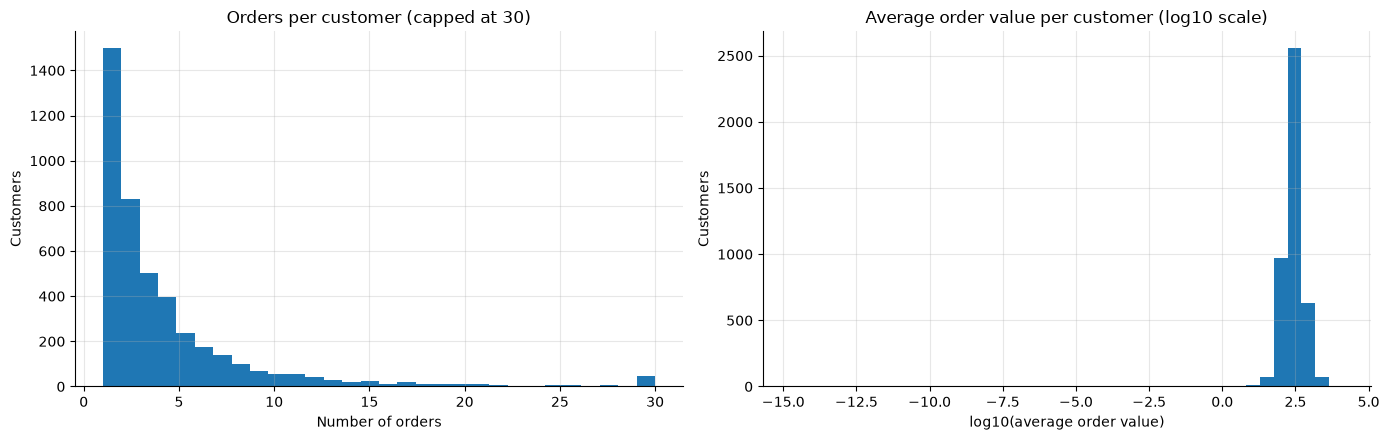

,Orders,AvgOrderValue
count,"4,325.00","4,325.00"
mean,4.25,369.00
std,7.64,464.70
min,1.00,0.00
25%,1.00,173.05
50%,2.00,281.20
75%,5.00,419.75
max,206.00,"13,206.50"


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(cust["Orders"].clip(upper=30), bins=30)
axes[0].set_title("Orders per customer (capped at 30)")
axes[0].set_xlabel("Number of orders")
axes[0].set_ylabel("Customers")
axes[1].hist(np.log10(cust["AvgOrderValue"]), bins=40)
axes[1].set_title("Average order value per customer (log10 scale)")
axes[1].set_xlabel("log10(average order value)")
axes[1].set_ylabel("Customers")
plt.tight_layout()
save(fig, "customer_orders_aov")
plt.show()

cust[["Orders", "AvgOrderValue"]].describe()

### What the order-count and order-value charts show
- **Many customers buy once or twice.** About 35% of customers placed a single order, the median is 2 orders, and 75% placed 5 or fewer. A small group orders much more often (the highest has 206 orders); the last bar groups everyone with 30 or more.
- **Typical order value is fairly narrow.** The middle half of customers average between about £173 and £420 per order (median about £281). A few trade-style customers reach several thousand pounds.
- **Customers differ more in how often they buy than in how much they spend per order.** The middle half ranges from 1 to 5 orders (a five-fold range) but only about 2.4-fold in average order value.

**Why it matters:** getting one-time buyers to place a second order is a large opportunity, and Frequency is likely to be an important driver of the segments.

## 4. Revenue over time

Monthly net revenue, invoices and active known customers. The data ends in early December 2011, so the last month is incomplete and is drawn in a lighter colour. It must not be compared with a full month.

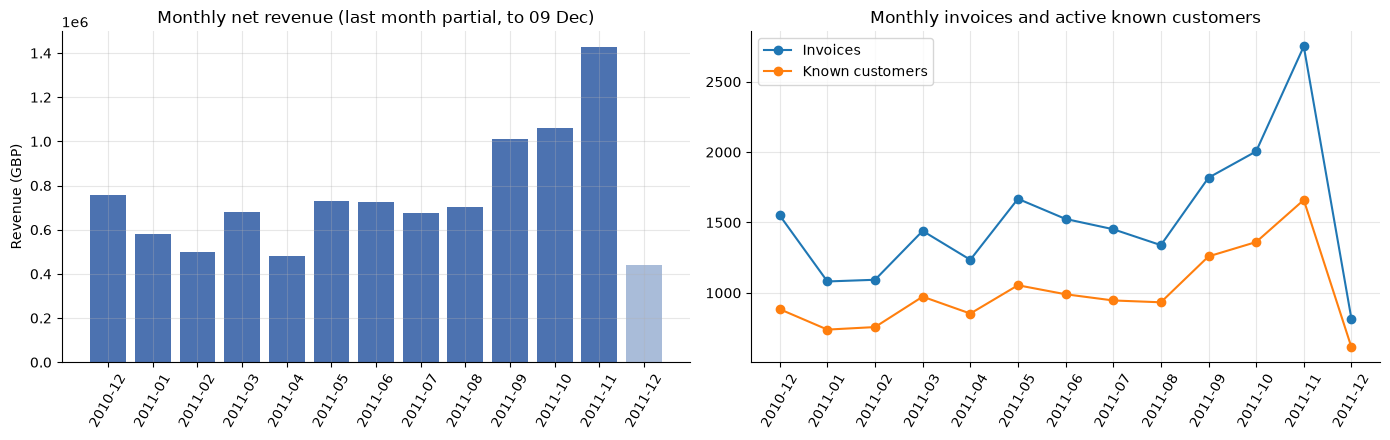

,Revenue,Invoices,KnownCustomers
InvoiceDate,,,
2010-12,"758,024.37",1550,884
2011-01,"578,836.94",1081,739
2011-02,"499,447.90",1093,757
2011-03,"679,204.19",1440,973
2011-04,"482,038.72",1235,853
2011-05,"730,966.12",1668,1054
2011-06,"723,845.14",1525,990
2011-07,"676,737.53",1452,946
2011-08,"701,270.19",1339,933


In [7]:
m_rev = lines.groupby(lines["InvoiceDate"].dt.to_period("M"))["Revenue"].sum()
m_cnt = sales.groupby(sales["InvoiceDate"].dt.to_period("M")).agg(
    Invoices=("InvoiceNo", "nunique"),
    KnownCustomers=("CustomerID", "nunique"),
)
monthly = m_cnt.assign(Revenue=m_rev)[["Revenue", "Invoices", "KnownCustomers"]]
monthly.index = monthly.index.astype(str)

last = sales["InvoiceDate"].max()
partial = last.day < last.days_in_month
colors = ["#4C72B0"] * len(monthly)
if partial:
    colors[-1] = "#A9BCD9"

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].bar(monthly.index, monthly["Revenue"], color=colors)
axes[0].set_title("Monthly net revenue" + (f" (last month partial, to {last.strftime('%d %b')})" if partial else ""))
axes[0].set_ylabel("Revenue (GBP)")
axes[0].tick_params(axis="x", rotation=60)
axes[1].plot(monthly.index, monthly["Invoices"], marker="o", label="Invoices")
axes[1].plot(monthly.index, monthly["KnownCustomers"], marker="o", label="Known customers")
axes[1].set_title("Monthly invoices and active known customers")
axes[1].tick_params(axis="x", rotation=60)
axes[1].legend()
plt.tight_layout()
save(fig, "monthly_revenue")
plt.show()

monthly

### What the monthly charts show
- **Strong autumn peak.** Net revenue rises from about £0.70M in August to £1.01M in September, £1.06M in October and **£1.43M in November**, the highest month. September to November together bring in £3.50M, about 36% of all net revenue in the period.
- **More orders and more customers, not bigger orders.** Between August and November invoices roughly doubled (1,339 to 2,751) and active customers rose by about 80% (933 to 1,660), while revenue per invoice stayed about the same (roughly £520 in both months).
- **Quiet spring.** February (£0.50M) and April (£0.48M) are the weakest full months.
- **December 2011 is incomplete.** The light bar covers only the first 9 days, so it must not be compared with other months or read as a drop.

**Why it matters:** stock, staff and marketing need to be ready before September. With only about one year of data we cannot separate a yearly seasonal pattern from general growth.

## 5. Weekday and hour patterns

We report both total revenue and revenue per *active* day, because a weekday that is absent or rare in the data would otherwise look weak for the wrong reason.

               Revenue  Invoices  DaysWithSales  RevenuePerActiveDay
DayOfWeek                                                           
Monday    1,622,110.41  3,076.00          47.00            34,512.99
Tuesday   1,967,975.35  3,509.00          52.00            37,845.68
Wednesday 1,738,728.78  3,667.00          53.00            32,806.20
Thursday  2,080,448.85  4,209.00          53.00            39,253.75
Friday    1,570,856.43  3,109.00          50.00            31,417.13
Saturday           NaN       NaN            NaN                  NaN
Sunday      790,799.89  2,203.00          50.00            15,816.00


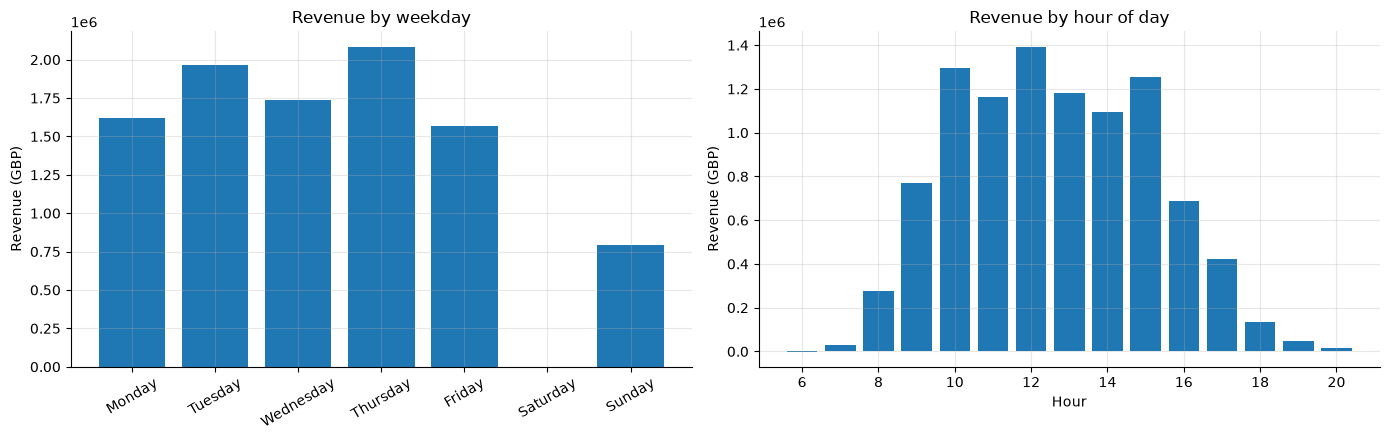

Weekdays with no sales at all: ['Saturday']


In [8]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

wd = sales.groupby("DayOfWeek").agg(
    Invoices=("InvoiceNo", "nunique"),
    DaysWithSales=("InvoiceDate", lambda s: s.dt.normalize().nunique()),
)
wd.insert(0, "Revenue", lines.groupby("DayOfWeek")["Revenue"].sum())
wd = wd.reindex(order)
wd["RevenuePerActiveDay"] = wd["Revenue"] / wd["DaysWithSales"]
print(wd.to_string())

hr = sales.groupby("Hour").agg(Invoices=("InvoiceNo", "nunique"))
hr.insert(0, "Revenue", lines.groupby("Hour")["Revenue"].sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].bar(order, wd["Revenue"].fillna(0))
axes[0].set_title("Revenue by weekday")
axes[0].set_ylabel("Revenue (GBP)")
axes[0].tick_params(axis="x", rotation=30)
axes[1].bar(hr.index, hr["Revenue"])
axes[1].set_title("Revenue by hour of day")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Revenue (GBP)")
plt.tight_layout()
save(fig, "weekday_hour")
plt.show()

missing_days = [d for d in order if wd.loc[d, "DaysWithSales"] == 0 or pd.isna(wd.loc[d, "DaysWithSales"])]
print("Weekdays with no sales at all:", missing_days if missing_days else "none")

### What the weekday and hour charts show
- **No sales on Saturdays.** The data has no transactions on any Saturday, which looks like a feature of how the business operates (or of how the data was recorded) rather than a weak day.
- **Thursday is the strongest day**, both in total (£2.08M) and per active day (about £39,254). Tuesday follows, and Friday is the weakest weekday per active day (about £31,417).
- **Sunday is much quieter** at about £15,816 per active day, roughly 40% of Thursday.
- **Why we use "per active day":** Monday has only 47 active days against 52 or 53 for Tuesday to Thursday, so totals alone understate it.
- **Orders cluster in working hours.** Revenue builds from 8:00, stays high between 10:00 and 15:00 (peaks around 12:00) and drops sharply after 16:00. That window holds roughly three quarters of revenue, which is consistent with trade customers ordering during the working day.

**Why it matters:** promotions and emails fit best on Tuesday to Thursday mornings; customer service and fulfilment cover matters most 10:00 to 15:00. Weekday and hour revenue is net and is booked when a cancellation was entered.

## 6. Pareto: revenue concentration

Do a small share of products generate most of the revenue? The curve ranks products from best to worst and accumulates their revenue share.

Products: 3,888
Products needed for 80% of revenue: 840 (21.6% of products)
Top 20% of products generate 78.2% of revenue


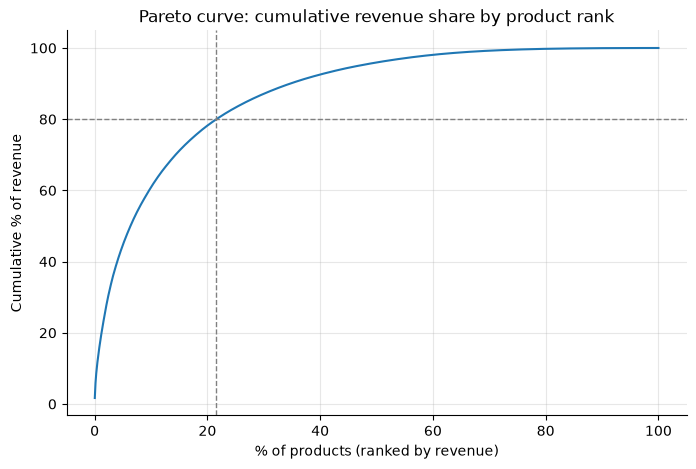

In [9]:
pr = prod["Revenue"].sort_values(ascending=False)
cum = pr.cumsum() / pr.sum()
share_products = np.arange(1, len(pr) + 1) / len(pr)

n80 = int((cum < 0.8).sum() + 1)
print(f"Products: {len(pr):,}")
print(f"Products needed for 80% of revenue: {n80:,} ({n80/len(pr):.1%} of products)")
print(f"Top 20% of products generate {cum.iloc[int(np.ceil(len(pr)*0.2)) - 1]:.1%} of revenue")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(share_products * 100, cum * 100)
ax.axhline(80, color="grey", linestyle="--", linewidth=1)
ax.axvline(n80 / len(pr) * 100, color="grey", linestyle="--", linewidth=1)
ax.set_title("Pareto curve: cumulative revenue share by product rank")
ax.set_xlabel("% of products (ranked by revenue)")
ax.set_ylabel("Cumulative % of revenue")
save(fig, "pareto_products")
plt.show()

### What the Pareto curve shows
- **The 80/20 rule roughly holds.** 840 products (21.6% of 3,888) generate 80% of revenue, and the top 20% of products generate 78.2%.
- **A long tail of small products.** The curve flattens quickly, so the least successful 40% of products contribute only a few percent of revenue (about 2%, read from the curve).
- **But it is not dependent on a few items.** Together with the 8.2% top-ten share from section 2, this means revenue comes from a broad core of several hundred products, not a handful of stars.

**Why it matters:** range reviews should focus on the core of about 840 products (availability, pricing, promotion), and the long tail can be reviewed for simplification without much revenue at risk.

## 7. Dead stock

*Dead stock* = products with historical sales but no sale in the last 90 days of the data. We measure from the day after the last invoice. Seasonal items (for example summer or Christmas products) can look dead simply because of the time of year, so the list needs to be read with that in mind.

In [10]:
ref = sales["InvoiceDate"].max().normalize() + pd.Timedelta(days=1)
cutoff = ref - pd.Timedelta(days=90)
print("Reference date:", ref.date(), "| no sale since:", cutoff.date())

prod["Dead90"] = prod["LastSale"] < cutoff
dead = prod[prod["Dead90"]]

print(f"Dead products     : {len(dead):,} of {len(prod):,} ({len(dead)/len(prod):.1%})")
print(f"Their revenue     : {dead['Revenue'].sum():,.0f} ({dead['Revenue'].sum()/prod['Revenue'].sum():.1%} of total)")
print(f"Their units       : {dead['Units'].sum():,} ({dead['Units'].sum()/prod['Units'].sum():.1%} of total)")

print("\nMonth of last sale for dead products")
print(dead["LastSale"].dt.to_period("M").value_counts().sort_index().to_string())

dead.nlargest(15, "Revenue")[["Description", "Units", "Revenue", "LastSale"]]

Reference date: 2011-12-10 | no sale since: 2011-09-11
Dead products     : 668 of 3,888 (17.2%)
Their revenue     : 187,901 (1.9% of total)
Their units       : 102,283 (1.9% of total)

Month of last sale for dead products
LastSale
2010-12     90
2011-01     39
2011-02     36
2011-03     67
2011-04    103
2011-05     83
2011-06     70
2011-07     81
2011-08     75
2011-09     24
Freq: M


,Description,Units,Revenue,LastSale
StockCode,,,,
47556B,TEA TIME TEA TOWELS,2600,"6,045.00",2011-04-18 13:20:00
22783,SET 3 WICKER OVAL BASKETS W LIDS,463,"5,961.25",2011-06-14 11:28:00
22088,PAPER BUNTING COLOURED LACE,1837,"5,511.85",2011-07-06 10:41:00
21033,JUMBO BAG CHARLIE AND LOLA TOYS,1931,"4,849.94",2011-09-08 13:53:00
21658,GLASS BEURRE DISH,846,"3,585.20",2011-08-11 10:14:00
22926,IVORY GIANT GARDEN THERMOMETER,579,"3,567.60",2011-05-10 10:00:00
85132C,CHARLIE AND LOLA FIGURES TINS,1515,"3,552.57",2011-09-02 09:38:00
21527,RED RETROSPOT TRADITIONAL TEAPOT,443,"3,464.69",2011-05-15 16:02:00
22760,"TRAY, BREAKFAST IN BED",269,"3,417.16",2011-09-05 10:00:00


### What the dead-stock summary shows
- **Dead stock is common but small in value.** 668 of 3,888 products (17.2%) had no sale in the last 90 days, yet together they account for only 1.9% of revenue and 1.9% of units.
- **Even the largest "dead" products earned little.** The best one (TEA TIME TEA TOWELS) made £6,045 over the whole period, about 0.06% of net revenue, compared with £164,459 for the top product.
- **Some are borderline.** A product whose last sale was a few days before the cut-off date (for example 8 September) may simply have a slow selling rhythm rather than being dead.

**Important limit:** the data has no stock levels, so "dead" means "no sales recently", not "unsold inventory". Some of these products may have been discontinued on purpose.

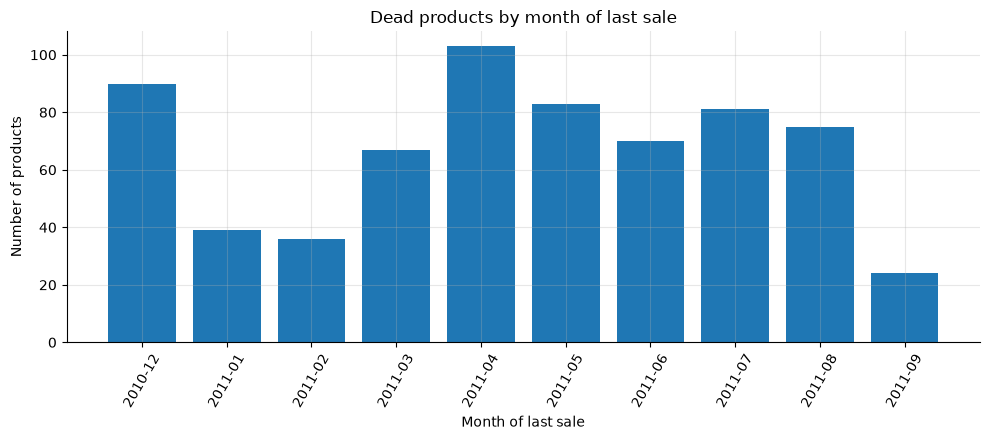

In [11]:
fig, ax = plt.subplots(figsize=(10, 4.5))
m = dead["LastSale"].dt.to_period("M").value_counts().sort_index()
ax.bar(m.index.astype(str), m.values)
ax.set_title("Dead products by month of last sale")
ax.set_xlabel("Month of last sale")
ax.set_ylabel("Number of products")
ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
save(fig, "dead_stock")
plt.show()

### What the dead-stock chart shows
- **Products fade out all year, not at one moment.** The number of dead products by month of last sale ranges from 24 (September) to 103 (April), with no single season dominating.
- **Dec 2010 has a high bar (90 products).** These sold only in the first month of the data, which may include Christmas items or products that were already being phased out before the data begins.

**Why it matters:** the pattern points to a steady, ongoing range clean-up rather than a one-off seasonal clearance.

## 8. Business insights

Each insight follows *finding → evidence → so what*, uses descriptive wording only (no causal claims), and cites numbers from this notebook. Customer figures are rounded because they depend on net revenue rounded to pence; re-check them after the final run.

| # | Finding | Evidence | So what for the business |
|---|---|---|---|
| 1 | Cancelled orders distort gross figures | Gross sales £10.25M vs net £9.77M (£475,901, 4.6% reversed). PAPER CRAFT, LITTLE BIRDIE: 80,995 units fully returned; MEDIUM CERAMIC TOP STORAGE JAR: 95% returned | Use net revenue everywhere; compute RFM Monetary net of cancellations so reversed orders do not create fake top customers |
| 2 | Revenue is spread across a broad core of products | Top 10 products = 8.2% of revenue; 840 of 3,888 products (21.6%) give 80% | No dependence on a few hero products; range management should focus on the ~840 core products |
| 3 | Unit rankings and revenue rankings differ | Only 5 of the top 10 overlap. POPCORN HOLDER: 56,427 units, about £0.90/unit; REGENCY CAKESTAND: 12,996 units, about £12.65/unit | Judge products by revenue (ideally margin), not volume; cheap high-volume items add workload more than revenue |
| 4 | Customer revenue is highly concentrated and skewed | Mean about £1,912 vs median about £648; top 20% of customers about 74% of known revenue; top 10 about 17% | Retention of a small high-value group matters most; segmentation needs a log transform |
| 5 | A third of customers bought only once | About 35% single-order customers; median 2 orders per customer | Converting first-time buyers into repeat buyers is a major growth lever |
| 6 | High-value customers behave differently | Customer 14911: 198 orders at about £650; customer 12415: 20 orders at about £6,182; 4 of the top 10 customers are outside the UK | Frequency and Monetary capture different customer types; the segments should separate frequent buyers from large-order buyers |
| 7 | Strong autumn peak | September to November = £3.50M, about 36% of net revenue; November £1.43M is about double August (£0.70M) | Plan stock, staffing and campaigns before September; with one year of data, seasonality cannot be separated from growth |
| 8 | The autumn increase comes from more orders and customers, not larger orders | Nov vs Aug: invoices 2,751 vs 1,339; active customers 1,660 vs 933; revenue per invoice about £519 vs £524 | Activate and reactivate customers rather than aim to raise basket size |
| 9 | Sales happen Sunday to Friday, with Thursday strongest | No Saturday sales; Thursday about £39,254 per active day; Sunday about £15,816 (about 40% of Thursday) | Schedule promotions Tuesday to Thursday; check whether the absence of Saturday sales is real or a recording effect |
| 10 | Orders cluster in working hours | About three quarters of revenue between 10:00 and 15:00 (read from the chart); little before 8:00 or after 17:00 | Fulfilment and customer service cover matters most mid-day; the pattern is consistent with trade customers |
| 11 | Dead stock is common but financially small | 668 of 3,888 products (17.2%) unsold for 90 days, only 1.9% of revenue; the largest earned £6,045 in total | Low financial risk; review the long tail for clearance or removal (stock levels are needed to confirm) |
| 12 | Products fade out throughout the year | Dead products by month of last sale range from 24 to 103, with no single season dominating | Use a regular range review rather than a one-off seasonal clearance |
| 13 | Segmentation will cover about 85% of revenue | Known customers = 84.6% of net revenue; the rest is guest orders | State this limitation in the report; guest buyers cannot be segmented |

Further insights on geography, basket size, returns and seasonality are added from the second EDA notebook, and the numbering is merged in the final report.